# 78 hipótesis para 16 cánceres. Una pregunta incómoda.

Google DeepMind lanzó **Co-Scientist**, un sistema de varios agentes (montados sobre Gemini) que propone hipótesis científicas, las critica y las refina en un torneo interno. En el paper validan el sistema generando ideas para reposicionar medicamentos contra 16 tipos de cáncer.

El número que llama la atención está en la tabla 2 del supplementary: de las **78 propuestas totales**, **13 (17%)** fueron para leucemia mieloide aguda (AML). Y casualmente, AML es el único cáncer que los autores llevaron a validación in vitro.

Abrimos los datos del material suplementario y miramos qué soportan y qué no.

**Paper:** Gottweis et al., *Nature*, 2026 — [doi:10.1038/s41586-026-10644-y](https://doi.org/10.1038/s41586-026-10644-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-19-co-scientist/notebook.ipynb)

## Qué hay en los datos

El paper publica un **PDF de 119 páginas** como material suplementario. Dos tablas son cuantitativas:

- **Tabla 2** — distribución de las 78 propuestas de reposicionamiento de medicamentos (drug-repurposing) por tipo de cáncer (códigos TCGA: LAML, COAD, BRCA, etc.).
- **Tabla 1** — 7 métricas before/after de ablations sobre 3 agentes internos (Reflection, Evolution, Meta-review) para medir cuánto aporta cada uno.

No hay datos crudos de las líneas celulares (MOLM-13, HL-60, NOMO-1) que validaron in vitro (en placa, con células cultivadas — no en pacientes) — esos solo aparecen como gráficas de barras en el cuerpo principal del paper.

Veamos qué nos cuentan estas dos tablas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CANCER_FOCO = 'LAML'             # El cáncer que el paper validó in vitro
FUENTE = 'Fuente: Gottweis et al. (2026), Nature | Datos: Supplementary Information (Tablas 1 y 2)'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_GRIS = '#BBBBBB'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
df_cancers = pd.read_csv('datos/cancer_types_proposals.csv')
df_ablations = pd.read_csv('datos/agent_ablations.csv')

print(f'Cancers — {len(df_cancers)} tipos, total propuestas: {df_cancers["n_proposals"].sum()}')
print(f'Ablations — {len(df_ablations)} métricas, agentes: {df_ablations["agent"].unique().tolist()}')
df_cancers.head()

Cancers — 16 tipos, total propuestas: 78
Ablations — 7 métricas, agentes: ['Reflection', 'Evolution', 'Meta-review']


,cancer_code,cancer_name,n_proposals
0,LAML,Acute Myeloid Leukemia,13
1,COAD,Colon adenocarcinoma,10
2,BRCA,Breast invasive carcinoma,10
3,SKCM,Skin Cutaneous Melanoma,8
4,LUAD,Lung adenocarcinoma,6


## Aquí está la distribución.

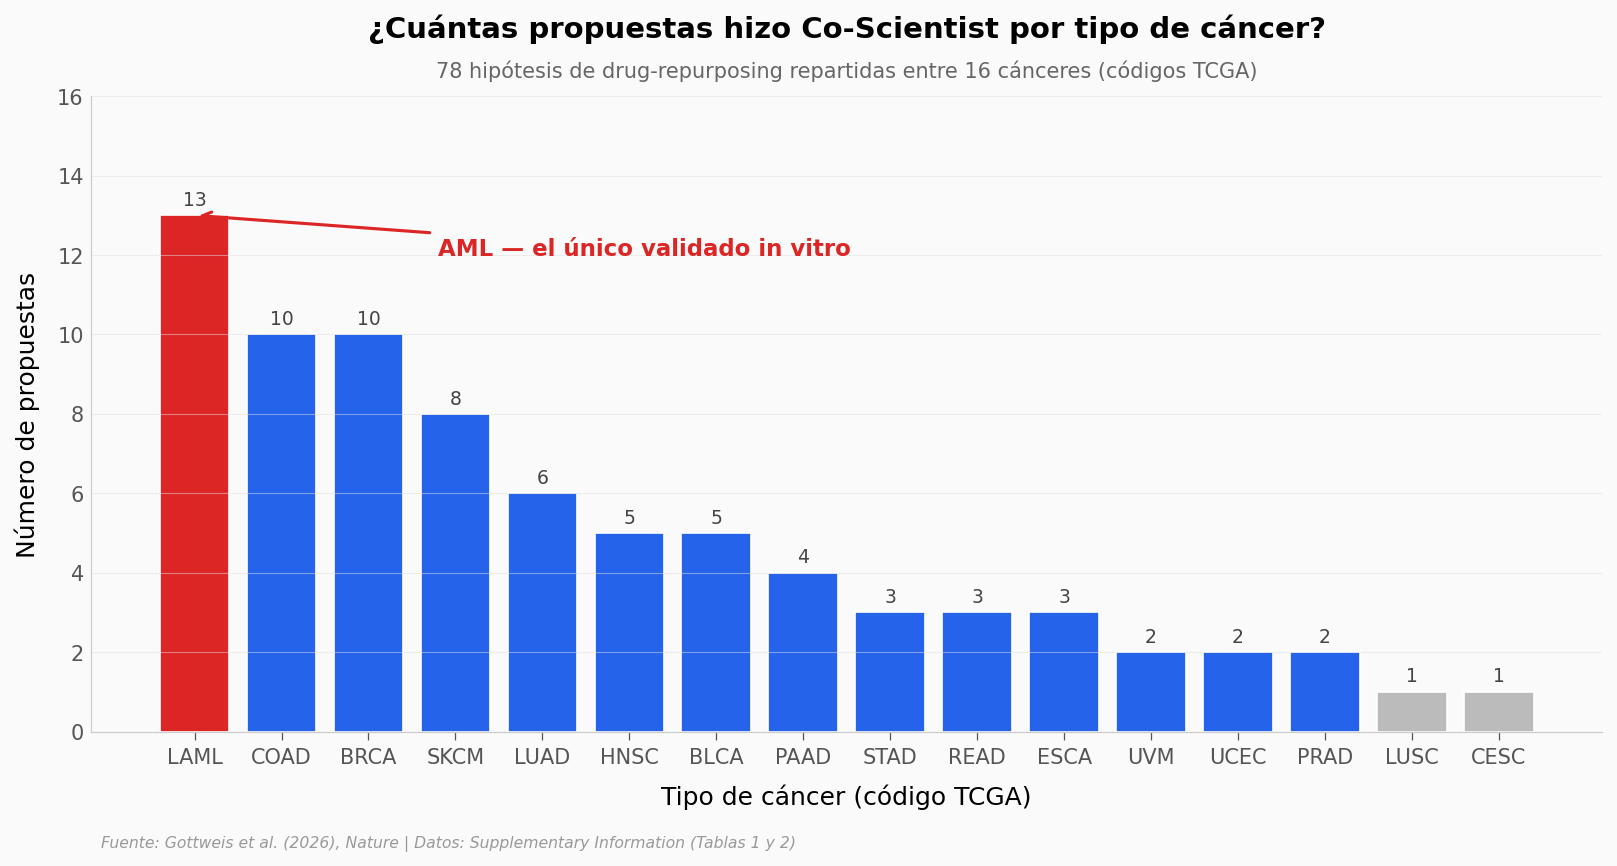

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por n_proposals descendente
df_plot = df_cancers.sort_values('n_proposals', ascending=False).reset_index(drop=True)

# Color: AML resaltado en rojo, resto en azul, los de 1-propuesta en gris
colors = []
for code, n in zip(df_plot['cancer_code'], df_plot['n_proposals']):
    if code == CANCER_FOCO:
        colors.append(COLOR_ALERTA)
    elif n == 1:
        colors.append(COLOR_GRIS)
    else:
        colors.append(COLOR_DATOS)

bars = ax.bar(df_plot['cancer_code'], df_plot['n_proposals'],
              color=colors, edgecolor='white', linewidth=0.8)

# Numero encima de cada barra
for bar, n in zip(bars, df_plot['n_proposals']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
            str(n), ha='center', fontsize=9, color='#444444')

# Anotación AML
laml_bar = bars[0]
ax.annotate('AML — el único validado in vitro',
            xy=(laml_bar.get_x() + laml_bar.get_width()/2, laml_bar.get_height()),
            xytext=(2.8, 12),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Cuántas propuestas hizo Co-Scientist por tipo de cáncer?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '78 hipótesis de drug-repurposing repartidas entre 16 cánceres (códigos TCGA)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Número de propuestas')
ax.set_xlabel('Tipo de cáncer (código TCGA)')
ax.set_ylim(0, 16)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_distribucion_cancers.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que llama la atención

- **LAML concentra el 17%** de las propuestas (13 de 78). Junto a colon (COAD, 10) y mama (BRCA, 10), los tres principales suman **42%** del total.
- La cola es larga: **5 cánceres** recibieron solo 1-2 propuestas cada uno.
- El paper no explica por qué la distribución está sesgada hacia LAML. Una posibilidad cómoda: los autores eligieron AML para validar in vitro *porque* Co-Scientist propuso muchas hipótesis ahí. Otra menos cómoda: el sistema fue afinado o sesgado, consciente o no, hacia el dominio donde iban a probarlo.

Los datos solos no resuelven esta pregunta — sólo la dejan visible.

## Cuánto aporta cada agente

Co-Scientist no es un solo modelo: combina varios agentes (Reflection, Evolution, Meta-review) que se critican y refinan entre sí. El paper hace ablations — comparar el sistema *con* vs *sin* cada agente — sobre 7 métricas. Veamos los deltas.

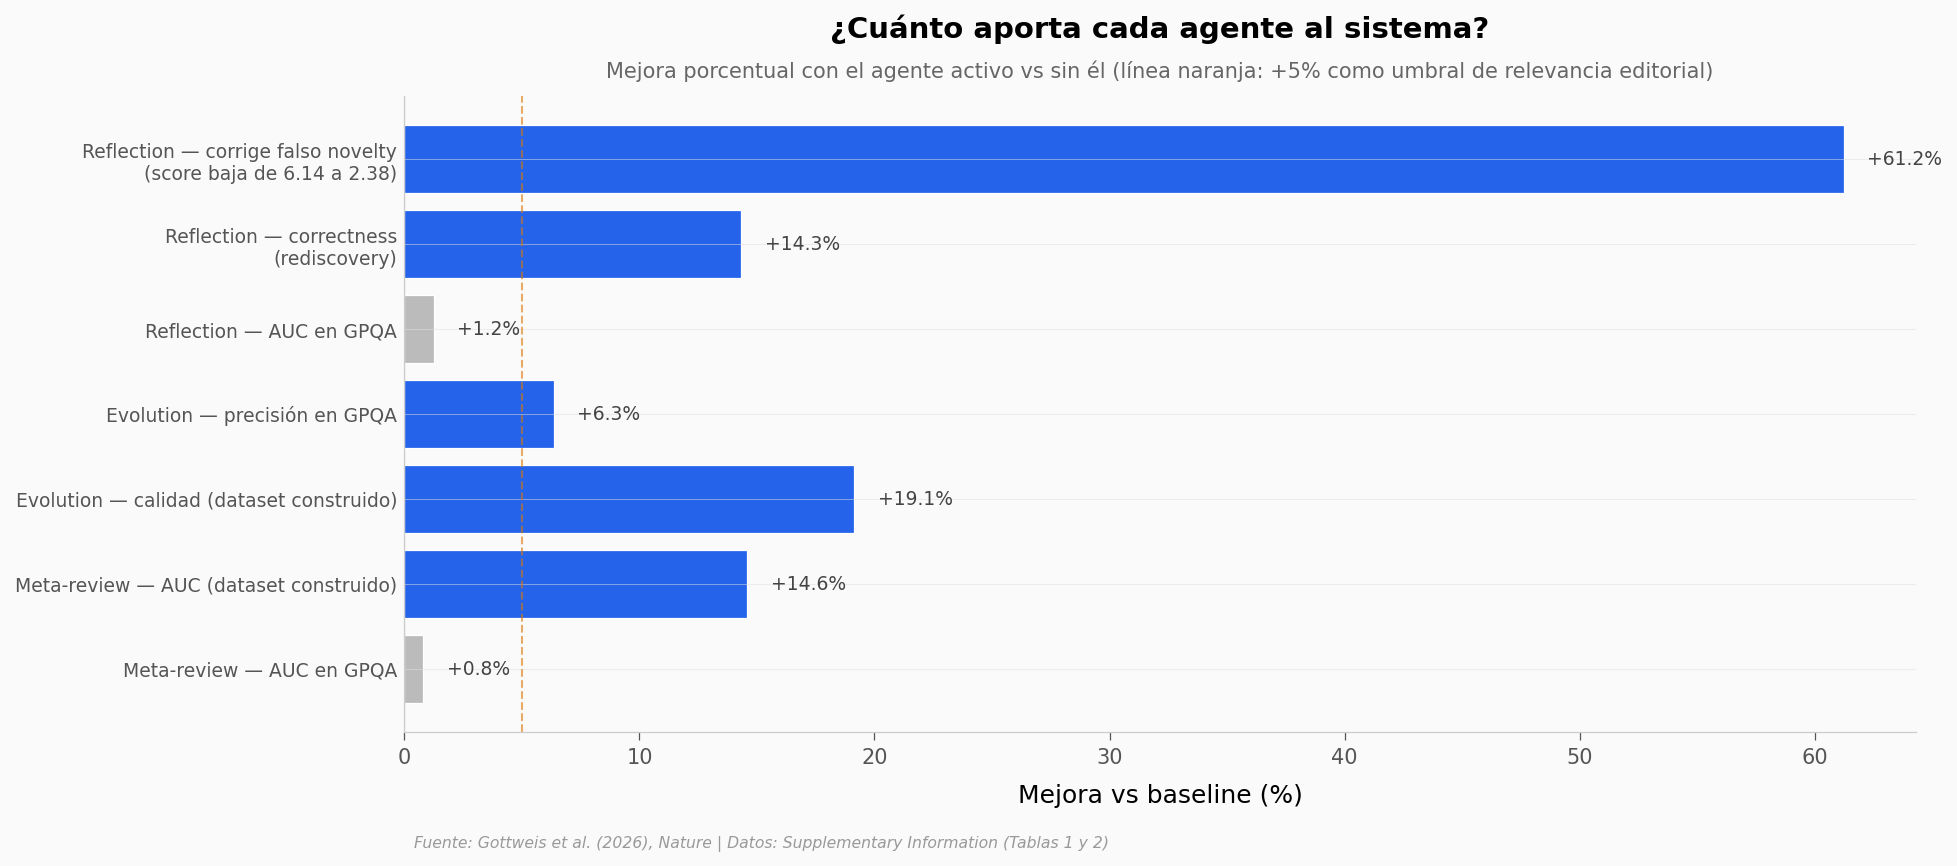

In [3]:
# Calcular % de cambio reportable
df_ab = df_ablations.copy()
df_ab['delta_pct'] = ((df_ab['enhanced'] - df_ab['baseline']) / df_ab['baseline']) * 100

# Caso especial: Reflection novelty_score sobre rediscovery — BAJAR es MEJORA
# (porque marca correctamente que la hipótesis NO es novel)
df_ab['mejora_pct'] = df_ab['delta_pct'].copy()
mask_rediscover = df_ab['metric'].str.contains('novelty') & df_ab['benchmark'].str.startswith('rediscovery')
df_ab.loc[mask_rediscover, 'mejora_pct'] = -df_ab.loc[mask_rediscover, 'delta_pct']

# Etiquetas legibles para cada métrica
labels = [
    'Reflection — corrige falso novelty\n(score baja de 6.14 a 2.38)',
    'Reflection — correctness\n(rediscovery)',
    'Reflection — AUC en GPQA',
    'Evolution — precisión en GPQA',
    'Evolution — calidad (dataset construido)',
    'Meta-review — AUC (dataset construido)',
    'Meta-review — AUC en GPQA',
]

fig, ax = plt.subplots(figsize=(13, 5.5))

# Color por dirección de mejora real (no signo crudo)
colors = [COLOR_DATOS if v > 5 else COLOR_GRIS for v in df_ab['mejora_pct']]

y_pos = np.arange(len(labels))
ax.barh(y_pos, df_ab['mejora_pct'], color=colors, edgecolor='white', linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.axvline(x=0, color='#999999', linewidth=1)
ax.axvline(x=5, color=COLOR_REFERENCIA, linewidth=1, linestyle='--', alpha=0.6)

# Etiquetas numéricas al final de cada barra
for i, v in enumerate(df_ab['mejora_pct']):
    ax.text(v + (1 if v >= 0 else -1), i, f'{v:+.1f}%',
            va='center', ha='left' if v >= 0 else 'right',
            fontsize=9, color='#444444')

ax.set_title('¿Cuánto aporta cada agente al sistema?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mejora porcentual con el agente activo vs sin él (línea naranja: +5% como umbral de relevancia editorial)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Mejora vs baseline (%)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_ablations.png', dpi=200, bbox_inches='tight')
plt.show()

### Cómo leer estos resultados

- **Mejoras fuertes (azul):** corregir falso novelty (+61% mejora), calidad con Evolution (+19%), AUC del meta-review en dataset construido (+15%), correctness con Reflection (+14%).
- **Mejoras marginales (gris):** los dos AUCs sobre GPQA — Reflection +1.2%, Meta-review +0.8% — caen por debajo del umbral editorial de +5%. La precisión de Evolution sobre GPQA (+6.3%) lo supera apenas. GPQA es un benchmark independiente; las mejoras más fuertes se concentran en benchmarks construidos por el equipo.
- El paper no reporta intervalos de confianza para estas ablations, así que los deltas pequeños podrían no distinguirse de ruido. Todo apunta a que el sistema gana más cuando lo evalúan con su propio rubro que con un benchmark externo.

## ¿Qué tan sesgada está la distribución?

Volvamos a las 78 propuestas. Si Co-Scientist fuera neutral entre los 16 cánceres, esperaríamos en promedio ~5 propuestas por tipo. La distribución real cuenta otra historia.

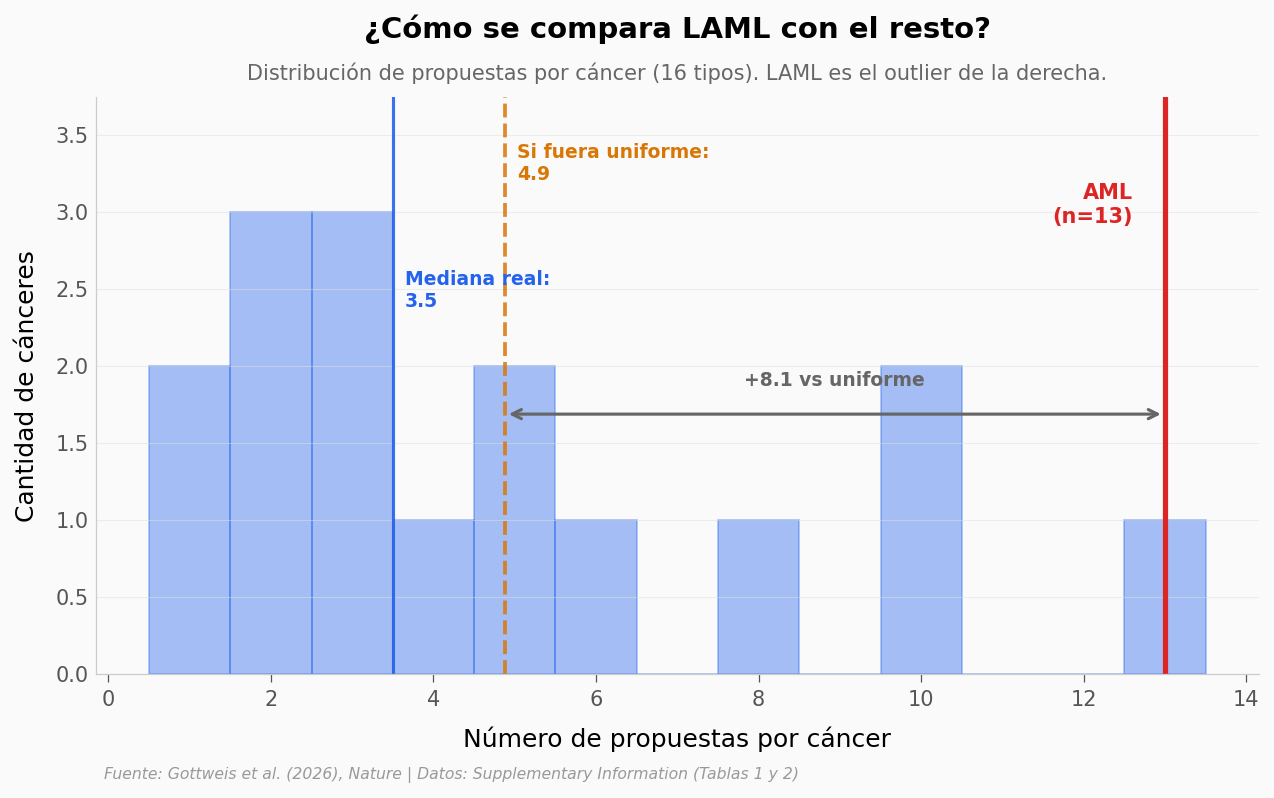

Mediana: 3.5 | IQR: [2.0, 6.5] | LAML: 13 | Si uniforme: 4.9


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = df_cancers['n_proposals'].values
n_bins = np.arange(0.5, vals.max() + 1.5, 1)
n, bins, patches = ax.hist(vals, bins=n_bins, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

mediana = np.median(vals)
media_uniforme = 78 / 16  # ~4.875
laml = 13

ax.axvline(x=media_uniforme, color=COLOR_REFERENCIA, linewidth=1.8, linestyle='--', alpha=0.85)
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5, alpha=0.9)
ax.axvline(x=laml, color=COLOR_ALERTA, linewidth=2.5)

# Etiquetas inline
ax.text(media_uniforme + 0.15, y_max*0.92, f'Si fuera uniforme:\n{media_uniforme:.1f}',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', va='top')
ax.text(mediana + 0.15, y_max*0.70, f'Mediana real:\n{mediana:.1f}',
        fontsize=9, color=COLOR_DATOS, fontweight='bold', va='top')
ax.text(laml - 0.4, y_max*0.85, f'AML\n(n={laml})',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', va='top', ha='right')

# Flecha bidireccional entre uniforme y AML
ax.annotate('', xy=(laml, y_max*0.45), xytext=(media_uniforme, y_max*0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = laml - media_uniforme
ax.text((laml + media_uniforme)/2, y_max*0.50, f'+{diff:.1f} vs uniforme',
        ha='center', fontsize=9, color='#666666', fontweight='bold')

ax.set_title('¿Cómo se compara LAML con el resto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de propuestas por cáncer (16 tipos). LAML es el outlier de la derecha.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de propuestas por cáncer')
ax.set_ylabel('Cantidad de cánceres')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana: {mediana} | IQR: [{np.percentile(vals, 25):.1f}, {np.percentile(vals, 75):.1f}] | '
      f'LAML: {laml} | Si uniforme: {media_uniforme:.1f}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Co-Scientist propuso 78 hipótesis de drug-repurposing en 16 cánceres | ✅ | Tabla 2 SI lo reporta literal; el conteo de filas coincide |
| LAML recibió el 17% de las propuestas (13 de 78) | ✅ | Cálculo directo sobre Tabla 2: 13/78 = 16.7% |
| El equipo validó in vitro 3 líneas celulares AML (MOLM-13, HL-60, NOMO-1) | ✅ | Tabla 4 SI las menciona en negrita como las usadas en el estudio |
| Co-Scientist mejora todas las métricas de ablation | ⚠️ | Sí, las 7/7 mejoran, pero **2 de las 7** lo hacen con deltas <2% (los AUCs sobre GPQA: Reflection +1.2%, Meta-review +0.8%). El paper no reporta intervalos de confianza |
| Co-Scientist "acelera el descubrimiento científico" | ⚠️ | El paper usa *potential to accelerate* en el abstract — el sistema **propone**, los humanos seleccionaron qué validar. No hay ensayos clínicos ni outcome real medido |
| La distribución por cáncer es neutral | ❌ | La distribución está fuertemente sesgada: mediana 3.5, AML con 13 es outlier (+2.7× la media uniforme) |

> **Limitaciones del dataset y análisis:**
> - **Validación solo en líneas celulares AML** — sin ensayos clínicos ni modelos animales. La distancia entre "funciona in vitro" y "funciona en pacientes" es enorme.
> - **Mejoras de AUC marginales en GPQA** (benchmark externo de preguntas científicas) — Reflection +1.2%, Meta-review +0.8%. Sin intervalos de confianza, podrían no distinguirse de ruido.
> - **Sistema cerrado** — Co-Scientist corre sobre Gemini (de código cerrado), lo que limita que terceros puedan reproducirlo de punta a punta.
> - **Sesgo de selección oculto** — el sesgo hacia LAML (17% de propuestas) podría reflejar la elección de dominio para validación, no una capacidad general del sistema.

## Ahora tú

Tres preguntas que puedes responder modificando la celda experimental:

1. **¿Y si excluyes los tres cánceres dominantes (LAML, COAD, BRCA)?** ¿Qué tan equilibrada se ve la distribución restante? Pista: filtra `df_cancers` y vuelve a calcular media/mediana.
2. **¿Cuál es el agente que más aporta promediando sus propias métricas?** Pista: agrupa `df_ablations` por `agent` y promedia `delta_pct`. ¿Es Reflection, Evolution o Meta-review?
3. **¿Qué pasaría con la mejora promedio si quitaras las métricas con deltas <2%?** Pista: filtra por `abs(delta_pct) > 2` y compara.

In [5]:
# --- EXPERIMENTA AQUÍ ---
# Promedio de mejora por agente (responde la pregunta 2)

df_ab_exp = df_ablations.copy()
df_ab_exp['delta_pct'] = ((df_ab_exp['enhanced'] - df_ab_exp['baseline']) / df_ab_exp['baseline']) * 100
# Corregir la métrica donde bajar es mejorar
mask = df_ab_exp['metric'].str.contains('novelty') & df_ab_exp['benchmark'].str.startswith('rediscovery')
df_ab_exp.loc[mask, 'delta_pct'] = -df_ab_exp.loc[mask, 'delta_pct']

por_agente = df_ab_exp.groupby('agent')['delta_pct'].agg(['mean', 'min', 'max', 'count'])
por_agente = por_agente.sort_values('mean', ascending=False)
print('Mejora promedio por agente:')
print(por_agente.round(2))

Mejora promedio por agente:
              mean   min    max  count
agent                                 
Reflection   25.60  1.24  61.24      3
Evolution    12.75  6.35  19.15      2
Meta-review   7.69  0.79  14.59      2


---

## Fuentes

**Paper**: [Accelerating scientific discovery with Co-Scientist](https://doi.org/10.1038/s41586-026-10644-y)  
*Nature, 2026-05-19*

**Supplementary Material**: [Supplementary Information — Notes 1-12, Figures 1-9, Tables 1-4 (119 pp)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10644-y/MediaObjects/41586_2026_10644_MOESM1_ESM.pdf)  
*Material suplementario del mismo paper (119 pp, PDF público)*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook reproducible** en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — licencia MIT (código) y CC-BY-4.0 (texto y figuras). Parte del proyecto **El Lab** de Ciencia a Mordiscos.